In [28]:
# !pip install torch tokenizers matplotlib seaborn requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
from tokenizers import Tokenizer, models, trainers, pre_tokenizers,decoders

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [29]:
#Load the Tiny Shakespeare text
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
if not os.path.exists('tinyshakespeare.txt'):
    with open('tinyshakespeare.txt', 'w', encoding='utf-8') as f:
        f.write(requests.get(url).text)

with open('tinyshakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Tokenization using BPE
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()
trainer = trainers.BpeTrainer(vocab_size=500, special_tokens=["[UNK]", "[PAD]"])

tokenizer.train_from_iterator([text], trainer=trainer)
encoded = tokenizer.encode(text)
tokens = torch.tensor(encoded.ids, dtype=torch.long)
vocab_size = tokenizer.get_vocab_size()

print(f"Total tokens in dataset: {len(tokens)}")
print(f"Vocabulary size: {vocab_size}")

Total tokens in dataset: 516697
Vocabulary size: 500


In [30]:
# Sequence formatting
seq_len = 50 # Fixed-length sequences

class ShakespeareDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

# Data split (80% Train, 20% Val)
split_idx = int(0.8 * len(tokens))
train_data = tokens[:split_idx]
val_data = tokens[split_idx:]

train_dataset = ShakespeareDataset(train_data, seq_len)
val_dataset = ShakespeareDataset(val_data, seq_len)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [31]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        norm = x.norm(2, dim=-1, keepdim=True) * (x.size(-1) ** -0.5)
        return (x / (norm + self.eps)) * self.weight

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, seq_len, dropout=0.2):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=False)
        self.n_head = n_head
        self.n_embd = n_embd
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        # Causal mask
        self.register_buffer("bias", torch.tril(torch.ones(seq_len, seq_len)).view(1, 1, seq_len, seq_len))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y, att

class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head, seq_len, dropout=0.2):
        super().__init__()
        self.ln_1 = RMSNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, seq_len, dropout)
        self.ln_2 = RMSNorm(n_embd)
        self.mlp = FeedForward(n_embd, dropout)

    def forward(self, x):
        attn_out, att_weights = self.attn(self.ln_1(x))
        x = x + attn_out
        x = x + self.mlp(self.ln_2(x))
        return x, att_weights

class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, seq_len, n_embd=128, n_head=4, n_layer=2, dropout=0.2):
        super().__init__()
        self.seq_len = seq_len
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_enc = PositionalEncoding(n_embd, seq_len)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([Block(n_embd, n_head, seq_len, dropout) for _ in range(n_layer)])
        self.ln_f = RMSNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.lm_head.weight = self.token_emb.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        x = self.token_emb(idx)
        x = self.pos_enc(x)
        x = self.drop(x)

        attn_maps = []
        for block in self.blocks:
            x, att = block(x)
            attn_maps.append(att)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss, attn_maps

In [32]:
n_embd = 128
n_head = 4
n_layer = 4   # Scaled up for better performance per your budget
dropout = 0.2
epochs = 8
learning_rate = 5e-4

model = TinyTransformer(vocab_size, seq_len, n_embd, n_head, n_layer, dropout).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.05)

train_losses, val_losses, val_perplexities = [], [], []
best_val_loss = float('inf')

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits, loss, _ = model(x, targets=y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits, loss, _ = model(x, targets=y)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    ppl = math.exp(avg_val_loss)
    val_perplexities.append(ppl)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {ppl:.4f}")

model.load_state_dict(torch.load('best_model.pt'))

Starting Training...
Epoch 01 | Train Loss: 3.9849 | Val Loss: 3.6917 | Val PPL: 40.1112
Epoch 02 | Train Loss: 3.1698 | Val Loss: 3.5526 | Val PPL: 34.9050
Epoch 03 | Train Loss: 2.9898 | Val Loss: 3.4903 | Val PPL: 32.7964
Epoch 04 | Train Loss: 2.8996 | Val Loss: 3.4586 | Val PPL: 31.7715
Epoch 05 | Train Loss: 2.8440 | Val Loss: 3.4309 | Val PPL: 30.9051
Epoch 06 | Train Loss: 2.8054 | Val Loss: 3.4273 | Val PPL: 30.7941
Epoch 07 | Train Loss: 2.7762 | Val Loss: 3.4078 | Val PPL: 30.1975
Epoch 08 | Train Loss: 2.7541 | Val Loss: 3.4096 | Val PPL: 30.2531


<All keys matched successfully>

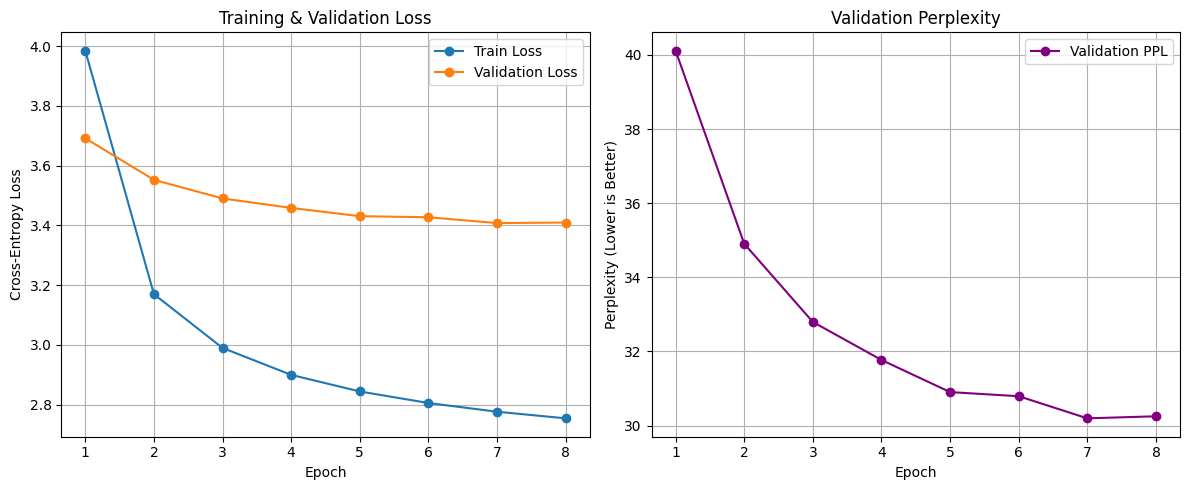

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_perplexities, label='Validation PPL', marker='o', color='purple')
plt.title('Validation Perplexity')
plt.xlabel('Epoch')
plt.ylabel('Perplexity (Lower is Better)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

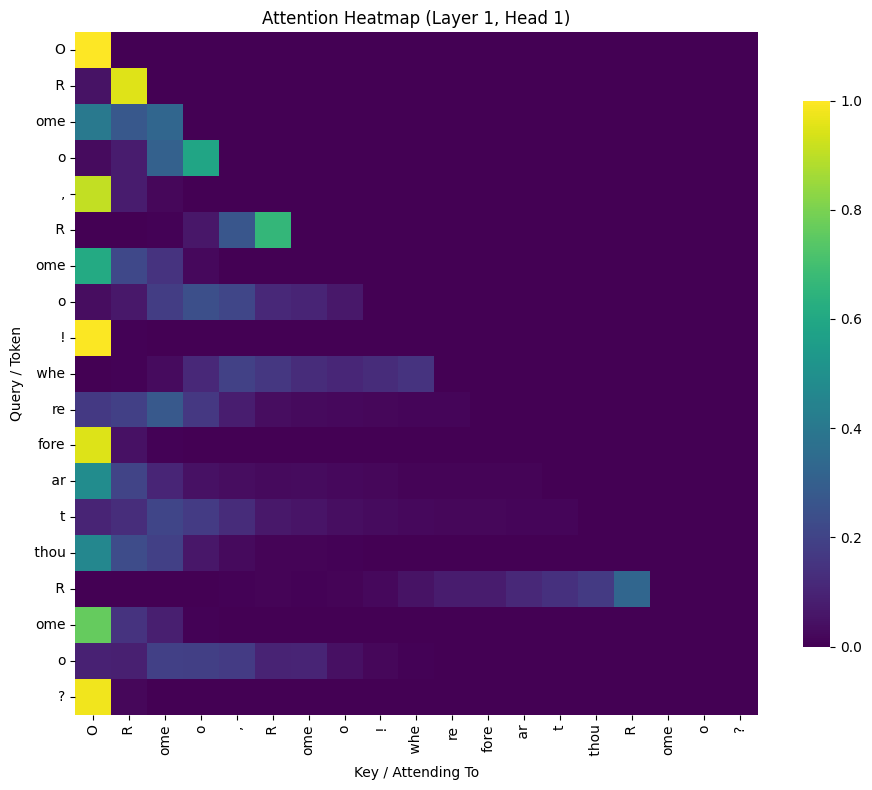

In [34]:
model.eval()
sample_text = "O Romeo, Romeo! wherefore art thou Romeo?"
sample_tokens = tokenizer.encode(sample_text).ids[:seq_len]
padded_tokens = sample_tokens + [0]*(seq_len - len(sample_tokens)) if len(sample_tokens) < seq_len else sample_tokens

x = torch.tensor([padded_tokens], dtype=torch.long).to(device)

with torch.no_grad():
    _, _, attn_maps = model(x)

layer_idx = 0
head_idx = 0
actual_len = len(sample_tokens)

attention_matrix = attn_maps[layer_idx][0, head_idx, :actual_len, :actual_len].cpu().numpy()

# Clean up tokens for matplotlib plotting (handles newlines)
tokens_str = [tokenizer.decode([t]).replace('\n', '\\n').replace('\r', '\\r') for t in sample_tokens]

plt.figure(figsize=(10, 8))
sns.heatmap(attention_matrix, xticklabels=tokens_str, yticklabels=tokens_str,
            cmap='viridis', square=True, cbar_kws={"shrink": .8})

plt.title(f'Attention Heatmap (Layer {layer_idx+1}, Head {head_idx+1})')
plt.xlabel('Key / Attending To')
plt.ylabel('Query / Token')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
def generate_text(model, start_text, max_new_tokens=50, temperature=0.8):
    model.eval()
    tokens = tokenizer.encode(start_text).ids
    idx = torch.tensor([tokens], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -seq_len:]
            logits, _, _ = model(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].cpu().tolist())

print("--- Generated Sample ---")
print(generate_text(model, "Romeo:\n", max_new_tokens=100))

--- Generated Sample ---
Romeo:
I am some scorn: in a month hath speech where
Agree could point forthful.

AUTOLYCUS:
Yes, young soul! where,' there is no men?

DUKE OF YORK:
You have been slain.

CORIOLANUS:
I was seem'd with thee!


